# 00 以480m数据清理

In [30]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean'
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        filepath = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(filepath)

        if 'lst_ratio' in gdf.columns:
            before_count = len(gdf)
            gdf_clean = gdf[gdf['lst_ratio'] >= 0.8]
            after_count = len(gdf_clean)

            if before_count != after_count:
                output_path = os.path.join(output_folder, filename)
                gdf_clean.to_file(output_path)
                print(f"✔ 清理 {filename}：原始 {before_count} 行，清理后 {after_count} 行")


✔ 清理 city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 2245 行，清理后 1861 行
✔ 清理 city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 2148 行，清理后 1572 行


# 00 根据480m的有效范围去裁剪120m和240m

In [32]:
import os
import geopandas as gpd

# 工作路径与数据路径
work_space = r'D:\seoul\grids\lst_map\final_clean'
year = 2016
data_file_120 = os.path.join(work_space, f'city{year}_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp')
data_file_240 = os.path.join(work_space, f'city{year}_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp')
data_file_480 = os.path.join(work_space, r'480_based', f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp')

output_space = os.path.join(work_space, '480_based')
os.makedirs(output_space, exist_ok=True)

def clean_file_by_within(input_file, base_file, output_file):
    gdf_input = gpd.read_file(input_file)
    gdf_base = gpd.read_file(base_file)

    # 确保投影一致
    if gdf_input.crs != gdf_base.crs:
        gdf_base = gdf_base.to_crs(gdf_input.crs)

    # 将 480m 网格合并为一个大的几何体集合
    base_union = gdf_base.unary_union
    gdf_filtered = gdf_input[gdf_input.geometry.buffer(-0.0001).within(base_union)]

    # # 判断每个小网格是否完全包含于480网格中
    # gdf_filtered = gdf_input[gdf_input.geometry.within(base_union)]

    # 保存输出
    gdf_filtered.to_file(output_file)
    print(f"✔ 完成清洗: {output_file}，保留 {len(gdf_filtered)} 个网格.")

# 输出路径定义
output_file_120 = os.path.join(output_space, os.path.basename(data_file_120))
output_file_240 = os.path.join(output_space, os.path.basename(data_file_240))

# 执行清洗
clean_file_by_within(data_file_120, data_file_480, output_file_120)
clean_file_by_within(data_file_240, data_file_480, output_file_240)


✔ 完成清洗: D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp，保留 29707 个网格.
✔ 完成清洗: D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp，保留 7442 个网格.


# 00 清理 120m 和 240m 的 lst_ratio <0.8

In [33]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        filepath = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(filepath)

        if 'lst_ratio' in gdf.columns:
            before_count = len(gdf)
            gdf_clean = gdf[gdf['lst_ratio'] >= 0.8]
            after_count = len(gdf_clean)

            if before_count != after_count:
                output_path = os.path.join(output_folder, filename)
                gdf_clean.to_file(output_path)
                print(f"✔ 清理 {filename}：原始 {before_count} 行，清理后 {after_count} 行")


✔ 清理 city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 29707 行，清理后 29283 行
✔ 清理 city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 7442 行，清理后 7338 行
✔ 清理 city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 25121 行，清理后 24306 行
✔ 清理 city2023_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：原始 6288 行，清理后 6093 行


# M -> KM

In [58]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        filepath = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(filepath)

        # 标记是否有修改
        modified = False

        # 转换三个距离字段：米 → 公里
        for col in ['Dist_WB', 'Dist_BP', 'Dist_MT']:
            if col in gdf.columns:
                gdf[col] = gdf[col] / 1000.0
                modified = True

        if modified:
            output_path = os.path.join(output_folder, filename)
            gdf.to_file(output_path)
            print(f"✔ 已更新 {filename}：三个距离字段已转换为公里")
        else:
            print(f"ℹ️ 跳过 {filename}：未找到指定字段")


✔ 已更新 city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2023_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里
✔ 已更新 city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp：三个距离字段已转换为公里


# 00 画一个新的区域范围图

In [38]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# 首尔行政边界
shp_seoul = r'D:\seoul\Final_data\Admin_boundary\Seoul_boundary.shp'
gdf_seoul = gpd.read_file(shp_seoul)

# 输出文件夹
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\figures'
os.makedirs(output_folder, exist_ok=True)
grid_sizes = [120,240,480]
for year in [2016,2023]:

    for i in grid_sizes:
        shp_path = rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_{i}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'

        gdf = gpd.read_file(shp_path)

        # 如果两者 CRS 不一致，投影到相同坐标系
        if gdf.crs != gdf_seoul.crs:
            gdf_seoul = gdf_seoul.to_crs(gdf.crs)

        fig, ax = plt.subplots(figsize=(8, 8))
        # 再叠加边界线
        gdf_seoul.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)
        # 先画格网
        gdf.plot(ax=ax, facecolor='lightgray', edgecolor='gray', linewidth=0.3)

        ax.set_title(f'Grid Size: {i}m', fontsize=14)
        ax.axis('off')

        output_path = os.path.join(output_folder, f'{year}_grid_{i}m_gray.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"✅ Saved: {output_path}")

✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2016_grid_120m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2016_grid_240m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2016_grid_480m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2023_grid_120m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2023_grid_240m_gray.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\2023_grid_480m_gray.png


# 00 基于480m的grid打标签FID_1 方便最后比较

In [35]:
years=[2016,2023]
for year in years:
    shp_path = rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    file_480= gpd.read_file(shp_path)
    file_480['FID_1'] = file_480.index
    file_480.to_file(shp_path)

In [36]:
import geopandas as gpd

def assign_fid_from_larger_grid(small_grid_path, large_grid_path, fid_field='FID_1'):
    """
    将较小网格的每个单元中心点匹配到较大网格中的FID，并写入原shapefile。

    Parameters:
        small_grid_path (str): 较小网格（如120m或240m）的Shapefile路径
        large_grid_path (str): 较大网格（如480m）的Shapefile路径，需包含FID字段
        fid_field (str): 在大网格中要匹配的字段名，默认是 'FID_1'
    """

    print(f"🔍 正在处理文件：{small_grid_path}")

    # 读取两个图层
    large_gdf = gpd.read_file(large_grid_path)
    small_gdf = gpd.read_file(small_grid_path)

    # 确保投影一致
    large_gdf = large_gdf.to_crs(small_gdf.crs)

    # 计算小网格中心点
    small_gdf['centroid'] = small_gdf.geometry.centroid
    centroids = gpd.GeoDataFrame(small_gdf[['centroid']], geometry='centroid', crs=small_gdf.crs)

    # 执行空间连接：中心点 within 大网格
    joined = gpd.sjoin(centroids, large_gdf[[fid_field, 'geometry']], how='left', predicate='within')

    # 将FID字段赋值给原始数据
    small_gdf[fid_field] = joined[fid_field].values

    # 删除中间计算列
    small_gdf = small_gdf.drop(columns='centroid')

    # 保存回原始路径
    small_gdf.to_file(small_grid_path)
    print(f"✔ 完成并保存：{small_grid_path}\n")

for year in [2016,2023]:
    for grid in [120,240]:
        assign_fid_from_larger_grid(
            small_grid_path=rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_{grid}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp',
            large_grid_path=rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
        )



🔍 正在处理文件：D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✔ 完成并保存：D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp

🔍 正在处理文件：D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✔ 完成并保存：D:\seoul\grids\lst_map\final_clean\480_based\city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp

🔍 正在处理文件：D:\seoul\grids\lst_map\final_clean\480_based\city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✔ 完成并保存：D:\seoul\grids\lst_map\final_clean\480_based\city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp

🔍 正在处理文件：D:\seoul\grids\lst_map\final_clean\480_based\city2023_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✔ 完成并保存：D:\seoul\grids\lst_map\final_clean\480_based\city2023_

# 00 画一下各个参数的图

In [43]:

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import numpy as np
# from mapclassify import Quantiles
from mapclassify import NaturalBreaks
# 输出文件夹
output_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored'
os.makedirs(output_folder, exist_ok=True)
seoul_boundary_file = r'D:\seoul\c_data\Admin_boundary\Seoul_boundary.shp'
shp_seoul = seoul_boundary_file

grid_sizes = [120, 240, 480]
for year in [2016, 2023]:
    # 可视化字段
    explanatory_vars = [f'ext_{year}',f'nor_{year}',f'hr_{year}','BCR(%)', 'BHA', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
    explanatory_vars_visual = [f'extreme',f'normal',f'HR','BCR (%)', 'BHA', 'BHV', 'NDVI', 'SVF', 'EV (m)',
                        'Dist_P', 'Dist_M', 'Dist_W', 'WR (%)']
    for value_column,name in zip(explanatory_vars,explanatory_vars_visual):
        for i in grid_sizes:

            shp_path = rf'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_{i}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'

            gdf = gpd.read_file(shp_path)
            boundary = gpd.read_file(shp_seoul)

            # 创建分级分类器
            classifier = NaturalBreaks(gdf[value_column], k=5)
            bins = classifier.bins
            gdf['class'] = classifier.yb  # 用于分类着色

            # 色带
            cmap = plt.get_cmap('RdYlBu_r')
            colors = cmap(np.linspace(0, 1, 5))
            # 统一坐标参考系
            if boundary.crs != gdf.crs:
                boundary = boundary.to_crs(gdf.crs)

            # 开始绘图
            fig, ax = plt.subplots(figsize=(9, 8))

            # 先绘制首尔边界
            boundary.plot(ax=ax, color='white', edgecolor='black', linewidth=1.0, zorder=0)

            # 再绘制分级网格
            for cls in range(5):
                gdf[gdf['class'] == cls].plot(ax=ax, color=colors[cls], linewidth=0.2, edgecolor='gray', zorder=1)

            # 设置标题
            ax.set_title(f'{year} {name} (Grid: {i}m)', fontsize=14)
            ax.axis('off')

            # 构建矩形 legend
            patches = []
            for j in range(5):
                if j == 0:
                    label = f'≤ {bins[j]:.2f}'
                else:
                    label = f'{bins[j-1]:.2f} - {bins[j]:.2f}'
                patch = mpatches.Patch(color=colors[j], label=label)
                patches.append(patch)

            # 添加图例到右边
            ax.legend(handles=patches,
                      title=name,  # ✅ 图例标题
                      loc='upper left',
                      bbox_to_anchor=(0.85, 0.95),
                      frameon=True)

            # 保存图像
            output_path = os.path.join(output_folder, f'{year}_{name}_{i}m_map.png')
            fig.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)  
            plt.savefig(output_path, dpi=300)

            plt.close()
            print(f"✅ Saved: {output_path}")

✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_extreme_120m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_extreme_240m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_extreme_480m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_normal_120m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_normal_240m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_normal_480m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_HR_120m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_HR_240m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_HR_480m_map.png
✅ Saved: D:\seoul\grids\lst_map\final_clean\480_based\figures\grids_colored\2016_BCR (%)_120m_map.pn

# 00 Descriptive statistics

In [89]:
import os
import re
import pandas as pd
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_folder = os.path.join(grid_folder, r'statistics')
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        input_path = os.path.join(grid_folder, filename)
        data = gpd.read_file(input_path)

for year in [2016, 2023]:
    output_path = os.path.join(output_folder, f'{year} Descriptive statistics.xlsx')
    all_stats = []
    
    for filename in os.listdir(grid_folder):
        if filename.endswith('_xy.shp') and filename.startswith(f'city{year}'):
            input_path = os.path.join(grid_folder, filename)
            df = gpd.read_file(input_path)

            raw_columns = [f'nor_{year}', f'ext_{year}', f'hr_{year}', 'BHA', 'BHV', 'BCR(%)', 'SVF', 'NDVI', 'EV(m)', 'WR(%)', 'Dist_BP', 'Dist_WB', 'Dist_MT']
            output_labels = ['Regular_LST (℃)', 'Extreme_LST (℃)', 'HR_T (℃)', 'BHA', 'BHV', 'BCR (%)', 'SVF', 'NDVI', 'EV (m)', 'WR (%)', 'Dist_P (km)', 'Dist_W (km)', 'Dist_M (km)']

            desc = df[raw_columns].describe().T[['mean', 'min', 'max', 'std']]
            desc.columns = ['Mean', 'Min', 'Max', 'SD']
            desc.index = output_labels
            desc = desc.round(2)

            # ✅ 提取 grid ID
            match = re.search(r'(\d{3,5})m', filename)
            grid_id = match.group(1) if match else 'Unknown'

            desc['Grid'] = grid_id

            # ✅ 添加观测值（每个 grid 有多少行）
            desc['N'] = len(df)

            all_stats.append(desc.reset_index())

    # 合并所有 grid 的结果
    summary_df = pd.concat(all_stats, ignore_index=True)
    summary_df.rename(columns={'index': 'Variable'}, inplace=True)

    # 输出 Excel
    summary_df.to_excel(output_path, index=False)
    print(f"📁 描述性统计合并完成！保存路径：{output_path}")


📁 描述性统计合并完成！保存路径：D:\seoul\grids\lst_map\final_clean\480_based\statistics\2016 Descriptive statistics.xlsx
📁 描述性统计合并完成！保存路径：D:\seoul\grids\lst_map\final_clean\480_based\statistics\2023 Descriptive statistics.xlsx


# 01 spatial regression model

## 00 先执行feature的correlation test, find out whether or not there has multicollinearity,用pearson, spearman还有传统VIF
比较出问题之后,剔除了BHA

① Pearson 相关系数（皮尔逊相关）
用于连续型变量之间的线性相关性检验。
范围：-1 到 1，越接近 ±1 说明线性关系越强。
适用：变量呈正态分布时。
from scipy.stats import pearsonr
r, p = pearsonr(x, y)

② Spearman 等级相关系数（斯皮尔曼相关）--> 在我们的研究中适用
用于连续或顺序变量之间的单调关系检验，不要求正态分布。
适用：非正态分布或有异常值时更稳健。
from scipy.stats import spearmanr
rho, p = spearmanr(x, y)

③ VIF（方差膨胀因子，Variance Inflation Factor）
用于检测自变量之间的多重共线性。
规则：VIF > 10（或 5）表示严重共线性，需剔除相关变量。
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = variance_inflation_factor(X.values, i)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor


for year in [2016,2023]:
    explanatory_vars = ['BCR(%)', 'BHA', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp') and filename.startswith(f'city{year}'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            df = gdf[explanatory_vars].dropna()

            # 📌 1. Pearson correlation matrix
            pearson_corr = df.corr(method='pearson')
            spearman_corr = df.corr(method='spearman')

            # 📌 2. Save correlation heatmaps
            fig, ax = plt.subplots(figsize=(10, 8))
            sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".3f", ax=ax)
            plt.title(f"Pearson Correlation Matrix ({year})")
            plt.tight_layout()
            plt.savefig(os.path.join(grid_folder, 'statistics', f"{year}_pearson_corr.png"))
            plt.close()

            fig, ax = plt.subplots(figsize=(10, 8))
            sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".3f", ax=ax)
            plt.title(f"Spearman Correlation Matrix ({year})")
            plt.tight_layout()
            plt.savefig(os.path.join(grid_folder, 'statistics', f"{year}_spearman_corr.png"))
            plt.close()

            # 📌 3. 计算 VIF
            df_vif = df.copy()
            df_vif["Intercept"] = 1  # 加上常数项

            vif_df = pd.DataFrame()
            vif_df["Variable"] = df_vif.columns
            vif_df["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

            # 删除 Intercept 行
            vif_df = vif_df[vif_df["Variable"] != "Intercept"]

            # 保存 VIF
            vif_path = os.path.join(grid_folder, 'statistics', f"{year}_VIF.xlsx")
            vif_df.to_excel(vif_path, index=False)

            print(f"✅ 变量相关性分析完成：{year}")

## 01 OLS regression models.

首先使用普通最小二乘法（Ordinary Least Squares, OLS）建立基础回归模型。
评估模型解释力和残差行为。

In [ ]:
import os
import geopandas as gpd
import statsmodels.api as sm
import re
import numpy as np
from spreg import OLS, LMtests

# 📁 文件夹路径
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'


for year in [2016,2023]:

    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp') and filename.startswith(f'city{year}'):
            filepath = os.path.join(grid_folder, filename)
            print(f"Processing {filename}...")

            # 读取 shapefile
            gdf = gpd.read_file(filepath)

            for target in target_vars:
                y = gdf[target]
                X = gdf[explanatory_vars]
                '''
                y = β₁X₁ + β₂X₂ + ...
                '''
                X = sm.add_constant(X)  # 添加截距项
                ''' -> 截距的意思是
                y = β₁X₁ + β₂X₂ + ...+ ε
                '''

                model = sm.OLS(y, X)
                results = model.fit()

                # 提取文件名中的 3~5 位数字
                match = re.search(r'grid_(\d{3,5})m', filename)
                file_id = match.group() if match else "Unknown"

                print(f"OLS results for {file_id} | target: {target}")
                #print(results.summary())

                print(f"R²: {results.rsquared:.4f}")
                rmse = np.sqrt(np.mean(results.resid ** 2))
                print(f"RMSE: {rmse:.4f}")

Processing city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp...
OLS results for grid_480m | target: nor_2016
R²: 0.8539
RMSE: 0.9577
OLS results for grid_480m | target: ext_2016
R²: 0.9055
RMSE: 1.2423
OLS results for grid_480m | target: hr_2016
R²: 0.8102
RMSE: 0.7770
Processing city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp...
OLS results for grid_480m | target: nor_2023
R²: 0.9206
RMSE: 1.1580
OLS results for grid_480m | target: ext_2023
R²: 0.8622
RMSE: 1.6241
OLS results for grid_480m | target: hr_2023
R²: 0.1298
RMSE: 1.3000


## 02 Moran’s I statistics:Test for Spatial Autocorrelation

使用 Moran’s I 统计量对 OLS 残差进行空间自相关检验。
若结果显著，说明存在空间自相关，OLS 模型不适用，需考虑空间回归模型。

In [29]:
import sys
# ! {sys.executable} -m pip install libpysal==4.6.0
import libpysal
print(libpysal.__version__)
# ! python.exe -m pip install --upgrade pip


4.13.0


In [61]:
import os
import geopandas as gpd
import numpy as np
from esda.moran import Moran
from libpysal.weights import Queen
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import connected_components

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp') and filename.startswith(f'city{year}'):
            filepath = os.path.join(grid_folder, filename)
            print(f"\n📂 Processing {filename}...")

            gdf = gpd.read_file(filepath)
        
            for target in target_vars:
                print(f"\n🔍 Analyzing variable: {target}")

                # 构建空间权重并移除孤岛
                w = Queen.from_dataframe(gdf, use_index=False)
                islands = [i for i, neighbors in w.neighbors.items() if len(neighbors) == 0]

                gdf_clean = gdf.drop(index=islands).reset_index(drop=True)
                # 构建权重矩阵
                w_clean = Queen.from_dataframe(gdf_clean, use_index=False)

                # 转为邻接矩阵
                adj_matrix = w_clean.full()[0]

                # 识别连通分量
                n_components, labels = connected_components(csgraph=adj_matrix, directed=False)

                # 找出最大连通分量的标签
                largest_label = np.bincount(labels).argmax()

                # 找出对应索引
                main_component = np.where(labels == largest_label)[0]

                # 筛选最大连通子图
                gdf_main = gdf_clean.iloc[main_component].reset_index(drop=True)

                # 重建空间权重矩阵
                w_main = Queen.from_dataframe(gdf_main, use_index=False)
                w_main.transform = 'r'

                y = gdf_main[target]

                # 计算 Moran's I
                moran = Moran(y, w_main)
        
                print(f"Moran's I: {moran.I:.4f}")
                print(f"p-value: {moran.p_sim:.4f}")
                print(f"Expected I: {moran.EI:.4f}")
                print(f"Variance: {moran.VI_sim:.4f}")

                if moran.p_sim < 0.05:
                    print(f"'{year}✅ Significant spatial autocorrelation detected.")
                else:
                    print("❌ No significant spatial autocorrelation detected.")
                


📂 Processing city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp...

🔍 Analyzing variable: nor_2016


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Moran's I: 0.6881
p-value: 0.0010
Expected I: -0.0006
Variance: 0.0002
'2016✅ Significant spatial autocorrelation detected.

🔍 Analyzing variable: ext_2016


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Moran's I: 0.6760
p-value: 0.0010
Expected I: -0.0006
Variance: 0.0002
'2016✅ Significant spatial autocorrelation detected.

🔍 Analyzing variable: hr_2016


...

Moran's I: 0.6775
p-value: 0.0010
Expected I: -0.0007
Variance: 0.0002
'2023✅ Significant spatial autocorrelation detected.

🔍 Analyzing variable: ext_2023


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Moran's I: 0.7007
p-value: 0.0010
Expected I: -0.0007
Variance: 0.0002
'2023✅ Significant spatial autocorrelation detected.

🔍 Analyzing variable: hr_2023


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Moran's I: 0.8606
p-value: 0.0010
Expected I: -0.0007
Variance: 0.0002
'2023✅ Significant spatial autocorrelation detected.


## 03 LM Test: Identify the Type of Spatial Dependence
使用 Lagrange Multiplier（LM）检验 判断空间依赖类型：
* LM-Lag（滞后型）：是否存在因变量的空间滞后项。
* LM-Error（误差型）：是否存在误差项的空间相关性。
* 同时参考 Robust LM-Lag 和 Robust LM-Error（控制另一种依赖类型后的检验）。
* 如果两个 Robust LM 检验都显著，说明两种依赖都可能存在，建议使用更一般形式的模型，如 SDM。

In [92]:
import os
import numpy as np
import geopandas as gpd
import libpysal
from spreg import OLS, LMtests

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
    # explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
    #                     'WR(%)']
    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp') and filename.startswith(f'city{year}'):
            filepath = os.path.join(grid_folder, filename)
            print(f"\nProcessing file: {filename}")

            gdf = gpd.read_file(filepath)
            w = libpysal.weights.Queen.from_dataframe(gdf, use_index=False)
            w.transform = 'r'

            for target in target_vars:
                print(f"\n→ Target variable: {target}")

                y = gdf[target].values.reshape(-1, 1)  # 变成二维数组
                X = gdf[explanatory_vars].values
                X = np.hstack((np.ones((X.shape[0], 1)), X))  # 添加常数项

                model = OLS(y, X, w=w, spat_diag=True, name_y=target, name_x=['const'] + explanatory_vars)
                
                # LMtests需要的是spreg的OLS结果，直接从model拿
                lms = LMtests(model, w)
                print(dir(lms))

                print(f"  LM-Lag (lml)                   : {lms.lml[0]:.4f}, p-value = {lms.lml[1]:.4g}")
                print(f"  LM-Error (lme)                 : {lms.lme[0]:.4f}, p-value = {lms.lme[1]:.4g}")
                print(f"  Robust LM-Lag (rlml)           : {lms.rlml[0]:.4f}, p-value = {lms.rlml[1]:.4g}")
                print(f"  Robust LM-Error (rlme)         : {lms.rlme[0]:.4f}, p-value = {lms.rlme[1]:.4g}")

                # if lms.lml[1] < 0.05 or lms.rlml[1] < 0.05:
                #     print("  Suggestion: Consider Spatial Lag Model (SLM).")
                # if lms.lme[1] < 0.05 or lms.rlme[1] < 0.05:
                #     print("  Suggestion: Consider Spatial Error Model (SEM).")
                # if (lms.rlml[1] < 0.05) and (lms.rlme[1] < 0.05):
                #     print("  Suggestion: Consider Spatial Durbin Model (SDM).")


Processing file: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp


c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')

→ Target variable: nor_2016
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'lme', 'lml', 'lmslxerr', 'lmspdurbin', 'lmwx', 'rlmdurlag', 'rlme', 'rlml', 'rlmwx', 'sarma']
  LM-Lag (lml)                   : 211.3825, p-value = 6.859e-48
  LM-Error (lme)                 : 1652.8657, p-value = 0
  Robust LM-Lag (rlml)           : 16.2983, p-value = 5.411e-05
  Robust LM-Erro

c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(self, neighbors, ids=ids, **kw)


## 04 Model Comparison: Likelihood Ratio (LR) Tests
在模型之间进行似然比检验（Likelihood Ratio Test），判断引入空间项后模型改进是否显著。
比较：
OLS vs SEM / SLM / SDM
SLM vs SDM / SEM vs SDM
SLM(SAR) vs SAC vs SDM

In [3]:
import sys
!{sys.executable} -m pip install --upgrade spreg
!{sys.executable} -m pip install --upgrade libpysal

  Using cached libpysal-4.13.0-py3-none-any.whl.metadata (4.8 kB)
Using cached libpysal-4.13.0-py3-none-any.whl (2.8 MB)
  Attempting uninstall: libpysal
    Found existing installation: libpysal 4.6.0
    Uninstalling libpysal-4.6.0:
      Successfully uninstalled libpysal-4.6.0


In [123]:
import spreg
print(spreg.__version__)
# import sys
# !{sys.executable} -m pip install --upgrade spreg 


1.8.3


In [128]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import libpysal
from spreg import OLS, ML_Lag, ML_Error
from spreg.diagnostics import likratiotest
import time
from scipy.stats import chi2

# 文件夹路径
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

# 初始化 DataFrame 保存结果
lr_results = pd.DataFrame(columns=[
    'Year', 'City', 'Dependent', 'Test', 'LR_stat', 'df', 'p_value'
])
model_info = pd.DataFrame(columns=[
    'Year', 'City', 'Dependent', 'Model', 'Variable', 'Coef', 'Std_err', 't_stat', 'p_value', 'R2', 'Adj_R2', 'Rho'
])

# 循环年份
for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp') and filename.startswith(f'city{year}'):
            path = os.path.join(grid_folder, filename)
            print(f"\nProcessing {filename}")
            gdf = gpd.read_file(path)

            # 构造空间权重矩阵（1000米阈值距离）
            threshold = 1000
            w = libpysal.weights.DistanceBand.from_dataframe(gdf, threshold=threshold, binary=False)
            w.transform = 'r'

            # 构造 y, X
            X0 = gdf[explanatory_vars].values
            x = np.hstack([np.ones((len(gdf), 1)), X0])  # 加常数列

            city_name = filename.split('_')[0]
            w_name = 'W1000'
            ds_name = f'yr{year}'

            for target in target_vars:
                yi = gdf[[target]].values
                models = {}

                # 1. OLS
                models['OLS'] = OLS(yi, x, w=w, spat_diag=True, moran=True,
                                    name_w=w_name, name_ds=ds_name)
                # SLX
                models['SLX'] = OLS(yi, x, w=w, slx_lags=1, spat_diag=True, moran=True,
                 name_w=w_name,name_ds=ds_name)
                
                # 2. SLM
                models['SLM'] = ML_Lag(yi, x, w=w, method="full",
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'])

                # 3. SDM
                models['SDM'] = ML_Lag(yi, x, w=w, slx_lags=1,
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'],
                                       spat_diag=True)

                # 4. SEM
                models['SEM']  = ML_Error(yi, x, w=w, method="full",
                     name_w=w_name,name_ds=ds_name)

                # 5. SDEM
                models['SDEM']  = ML_Error(yi, x, w=w, slx_lags=1,
                    name_w=w_name, name_ds=ds_name)


                # 保存模型系数信息
                for mdl_name, mdl in models.items():
                    coef = mdl.betas.flatten()
                    var_names = ['const'] + explanatory_vars
                    if mdl_name in ['SLM', 'SDM']:
                        var_names += [f"W_{v}" for v in explanatory_vars]
                    if mdl_name == 'SDEM':
                        var_names += [f"W_{v}" for v in explanatory_vars]  # SDEM Durbin
                    se = mdl.std_err.flatten()
                    t_stat = coef / se
                    p_val = 2 * (1 - chi2.cdf(t_stat**2, 1))
                    R2 = getattr(mdl, 'r2', np.nan)
                    R2_adj = getattr(mdl, 'ar2', np.nan)
                    Rho = getattr(mdl, 'rho', np.nan)
                    if mdl_name in ['SEM', 'SDEM']:
                        Rho = getattr(mdl, 'lambda', np.nan)

                    for c, v, s, t, p in zip(coef, var_names, se, t_stat, p_val):
                        model_info = pd.concat([model_info, pd.DataFrame([{
                            'Year': year,
                            'City': city_name,
                            'Dependent': target,
                            'Model': mdl_name,
                            'Variable': v,
                            'Coef': c,
                            'Std_err': s,
                            't_stat': t,
                            'p_value': p,
                            'R2': R2,
                            'Adj_R2': R2_adj,
                            'Rho': Rho
                        }])], ignore_index=True)
                def safe_likratiotest(m0, m1):
                    res = likratiotest(m0, m1)
                    df_expected = len(m1.betas.flatten()) - len(m0.betas.flatten())
                    if res['df'] != df_expected:
                        print(f"⚠️ df mismatch: likratiotest={res['df']}, expected={df_expected}")
                        res['df'] = df_expected
                    return res
                # 提取 LR 检验
                lr_tests = {
                    'SLX-OLS': safe_likratiotest(models['OLS'], models['SLX']),
                    'SLM-OLS': safe_likratiotest(models['OLS'], models['SLM']),
                    'SDM-OLS': safe_likratiotest(models['OLS'], models['SDM']),
                    'SEM-OLS': safe_likratiotest(models['OLS'], models['SEM']),
                    'SDM-SLX': safe_likratiotest(models['SLX'], models['SDM']),
                    'SDM-SLM': safe_likratiotest(models['SLM'], models['SDM']),
                    'SDM-SEM': safe_likratiotest(models['SEM'], models['SDM']),
                    'SDEM-SLX': safe_likratiotest(models['SLX'], models['SDEM']),
                    'SDEM-SEM': safe_likratiotest(models['SEM'], models['SDEM']),
                }

                for test_name, res in lr_tests.items():
                    lr_results = pd.concat([lr_results, pd.DataFrame([{
                        'Year': year,
                        'City': city_name,
                        'Dependent': target,
                        'Test': test_name,
                        'LR_stat': res['likr'],
                        'df': res['df'],
                        'p_value': res['p-value']
                    }])], ignore_index=True)
                    print(f"{test_name}: df(likratiotest)={res['df']}, "
                            f"params_m0={len(models[test_name.split('-')[0]].betas.flatten())}, "
                            f"params_m1={len(models[test_name.split('-')[1]].betas.flatten())}")



# 保存 Excel
output_path = r'D:\seoul\grids\lst_map\final_clean\480_based\statistics\LR_test_results.xlsx'
with pd.ExcelWriter(output_path) as writer:
    lr_results.to_excel(writer, sheet_name='LR_tests', index=False)
    model_info.to_excel(writer, sheet_name='Model_info', index=False)


print(f"All LR test results and model info saved to {output_path}")


Processing city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
C:\Users\owner\AppData\Local\Temp\ipykernel_29800\2994932656.py:96: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_info = pd.concat([model_info, pd.DataFrame([{
C:\Users\owner\AppData\Local\Temp\ipykernel_29800\2994932656.py:131: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In

⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11


...

⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


⚠️ df mismatch: likratiotest=10, expected=9
SLX-OLS: df(likratiotest)=9, params_m0=19, params_m1=10
SLM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-OLS: df(likratiotest)=10, params_m0=20, params_m1=10
SEM-OLS: df(likratiotest)=1, params_m0=11, params_m1=10
SDM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDM-SLM: df(likratiotest)=9, params_m0=20, params_m1=11
SDM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
SDEM-SLX: df(likratiotest)=1, params_m0=20, params_m1=19
SDEM-SEM: df(likratiotest)=9, params_m0=20, params_m1=11
All LR test results and model info saved to D:\seoul\grids\lst_map\final_clean\480_based\statistics\LR_test_results.xlsx


## 00+ (AIC BIC 间接分析)需要一个方法比较SEM和SDM

In [133]:
# import numpy as np
# import pandas as pd
# import geopandas as gpd
# from shapely.geometry import Point
# import libpysal

# # ===== 1) 构造一个小测试数据（5个点，单位：米）=====
# # 如果你有真实 data_gdf（且是投影到米），直接用：
# # data_gdf = your_gdf.to_crs(XXXX)
# coords = [
#     (0, 0),
#     (300, 0),
#     (800, 0),
#     (0, 900),
#     (1200, 0),
# ]
# gdf = gpd.GeoDataFrame(geometry=[Point(xy) for xy in coords], crs="EPSG:5186")  # 例子用米制CRS

# threshold = 1000  # 1000米邻居阈值

# # ===== 2) 生成两种权重：binary 等权 vs 非 binary 衰减 =====
# w_bin = libpysal.weights.DistanceBand.from_dataframe(gdf, threshold=threshold, binary=True)
# w_bin.transform = 'r'  # 行标准化

# w_ker = libpysal.weights.DistanceBand.from_dataframe(gdf, threshold=threshold, binary=False)
# w_ker.transform = 'r'  # 行标准化 + 衰减信息保留

# # ===== 3) 打印前几行邻居列表和权重 =====
# def peek_weights(w, name, n_show=5):
#     print(f"\n=== {name} ===")
#     ids = list(w.neighbors.keys())[:n_show]
#     for i in ids:
#         neigh = w.neighbors[i]
#         weights = w.weights[i]
#         print(f"id {i} -> neighbors {neigh} ; weights {np.round(weights, 4)} ; row-sum={sum(weights):.2f}")

# peek_weights(w_bin, "Binary=True (等权, 行标准化后每个邻居权重≈1/度)")
# peek_weights(w_ker, "Binary=False (1/距离衰减, 行标准化后近邻更重)")

# # ===== 4) 可选：把稀疏矩阵导出查看 =====
# def weights_to_edges_df(w):
#     rows = []
#     for i, neighs in w.neighbors.items():
#         for j, wij in zip(neighs, w.weights[i]):
#             rows.append({"i": i, "j": j, "w_ij": wij})
#     return pd.DataFrame(rows)

# edges_bin = weights_to_edges_df(w_bin)
# edges_ker = weights_to_edges_df(w_ker)

# print(edges_bin)
# print(edges_ker)


In [140]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag, OLS
# ML_Error_Het

# 设置路径
grid_folder = r"D:\seoul\grids\lst_map\final_clean\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

results_list = []
def show_formula(model):
    coefs = model.betas.flatten()
    vars_ = model.name_x
    formula = f"{model.name_y[0]} = "
    terms = [f"{coef:.4f}*{var}" for coef, var in zip(coefs, vars_)]
    
    # 添加空间参数
    if hasattr(model, "rho"):
        terms.append(f"{model.rho:.4f}*Wy")
    if hasattr(model, "lambda_"):
        terms.append(f"{model.lambda_:.4f}*error")
    
    formula += " + ".join(terms)
    return formula


for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']

    for filename in os.listdir(grid_folder):
        if filename.endswith('.shp') and filename.startswith(f'city{year}_lst_ratio_grid_480m'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print("CRS:", data_gdf.crs)
                # 创建基于距离的空间权重矩阵
                threshold = 1000
                # 设置binary = False, 就可以按照距离衰减
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 依然可以行标准化


                yi = np.array(data[target]).reshape(-1, 1)
                x = np.array(data[explanatory_vars])
                n, k = x.shape
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # === 模型估计 ===
                models = {}

                # 1. SLX
                models['SLX'] = OLS(yi, x, w=w, slx_lags=1, spat_diag=True, moran=True,
                 name_w=w_name,name_ds=ds_name)
                
                # 2. SLM
                models['SLM'] = ML_Lag(yi, x, w=w, method="full",
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'])

                # 3. SDM
                models['SDM'] = ML_Lag(yi, x, w=w, slx_lags=1,
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'],
                                       spat_diag=True)

                # 4. SEM
                models['SEM']  = ML_Error(yi, x, w=w, method="full",
                     name_w=w_name,name_ds=ds_name)

                # 5. SDEM
                models['SDEM']  = ML_Error(yi, x, w=w, slx_lags=1,
                    name_w=w_name, name_ds=ds_name)

                # === 提取 AIC, BIC, logLik ===
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算（β + 空间项 + σ²）
                    if model_name in ['SLX']:
                        n_params = k + k + 2  # k原始 + k滞后 + 常数 + σ²
                    elif model_name in ['SEM']:
                        n_params = k + 2      # k自变量 + λ + σ²
                    elif model_name in ['SLM']:
                        n_params = k + 2      # k自变量 + ρ + σ²
                    elif model_name in ['SDM', 'SDEM']:
                        n_params = 2 * k + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²
                    else:
                        n_params = k + 2

                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "File": filename,
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })
print(show_formula(models['SDM']))
print(show_formula(models['SDEM']))

# === 汇总输出 ===
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "SLX_SEM_SLM_SDM_SDEM_AIC_BIC.xlsx")
results_df.to_excel(output_path, index=False)

print(f"✅ 所有模型（SLX/SEM/SLM/SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support rel

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support rel

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


...

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: Run

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: Run

d = -8.6804*CONSTANT + -0.0189*var_1 + 0.0000*var_2 + 16.9822*var_3 + -1.9875*var_4 + 0.0038*var_5 + -0.2188*var_6 + 0.0195*var_7 + -0.1561*var_8 + 0.0733*var_9 + 0.0520*W_var_1 + 0.0434*W_var_2 + -13.9090*W_var_3 + 8.1095*W_var_4 + -0.0010*W_var_5 + 0.2625*W_var_6 + 0.0163*W_var_7 + 0.2044*W_var_8 + -0.0580*W_var_9 + 0.8436*W_dep_var + 0.8436*Wy
d = -11.9098*CONSTANT + -0.0118*var_1 + 0.0055*var_2 + 17.5085*var_3 + -0.3910*var_4 + 0.0032*var_5 + -0.0633*var_6 + 0.2823*var_7 + 0.0435*var_8 + 0.0736*var_9 + -0.0095*W_var_1 + -0.0192*W_var_2 + 0.6549*W_var_3 + -1.7580*W_var_4 + -0.0020*W_var_5 + 0.1307*W_var_6 + -0.1699*W_var_7 + 0.0795*W_var_8 + 0.0094*W_var_9 + 0.9173*lambda
✅ 所有模型（SLX/SEM/SLM/SDM/SDEM）AIC/BIC 结果已保存到：
D:\seoul\grids\lst_map\final_clean\480_based\statistics\SLX_SEM_SLM_SDM_SDEM_AIC_BIC.xlsx


In [136]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag, OLS
# ML_Error_Het

# 设置路径
grid_folder = r"D:\seoul\grids\lst_map\final_clean\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

results_list = []

for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']

    for filename in os.listdir(grid_folder):
        if filename.endswith('.shp') and filename.startswith(f'city{year}_lst_ratio_grid_480m'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print("CRS:", data_gdf.crs)
                # 创建基于距离的空间权重矩阵
                threshold = 1000
                # 设置binary = False, 就可以按照距离衰减
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 依然可以行标准化


                yi = np.array(data[target]).reshape(-1, 1)
                x = np.array(data[explanatory_vars])
                n, k = x.shape
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # === 模型估计 ===
                models = {}

                # 1. SLX
                models['SLX'] = OLS(yi, x, w=w, slx_lags=1, spat_diag=True, moran=True,
                 name_w=w_name,name_ds=ds_name)
                
                # 2. SLM
                models['SLM'] = ML_Lag(yi, x, w=w, method="full",
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'])

                # 3. SDM
                models['SDM'] = ML_Lag(yi, x, w=w, slx_lags=1,
                                       name_w=w_name, name_ds=ds_name,
                                       spat_impacts=['simple','full'],
                                       spat_diag=True)

                # 4. SEM
                models['SEM']  = ML_Error(yi, x, w=w, method="full",
                     name_w=w_name,name_ds=ds_name)

                # 5. SDEM
                models['SDEM']  = ML_Error(yi, x, w=w, slx_lags=1,
                    name_w=w_name, name_ds=ds_name)

                # === 提取 AIC, BIC, logLik ===
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算（β + 空间项 + σ²）
                    if model_name in ['SLX']:
                        n_params = k + k + 2  # k原始 + k滞后 + 常数 + σ²
                    elif model_name in ['SEM']:
                        n_params = k + 2      # k自变量 + λ + σ²
                    elif model_name in ['SLM']:
                        n_params = k + 2      # k自变量 + ρ + σ²
                    elif model_name in ['SDM', 'SDEM']:
                        n_params = 2 * k + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²
                    else:
                        n_params = k + 2

                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "File": filename,
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })

# === 汇总输出 ===
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "SLX_SEM_SLM_SDM_SDEM_AIC_BIC.xlsx")
results_df.to_excel(output_path, index=False)

print(f"✅ 所有模型（SLX/SEM/SLM/SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


...

c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


✅ 所有模型（SLX/SEM/SLM/SDM/SDEM）AIC/BIC 结果已保存到：
D:\seoul\grids\lst_map\final_clean\480_based\statistics\SLX_SEM_SLM_SDM_SDEM_AIC_BIC.xlsx


## 05 Model Selection Based on Diagnostics
选择合适的空间回归模型
检验结果	推荐模型
仅 LM-Error 显著	SEM（空间误差模型）
仅 LM-Lag 显著	SLM（空间滞后模型）
二者都显著	SDM（空间Durbin模型） 或进行进一步LR检验对比
SDM 是最一般的模型，可以退化为 SLM 或 SEM。
若 SDM 中某些系数不显著，可考虑退化为简化模型。

## AIC BIC 特殊建模

In [ ]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"D:\seoul\grids\lst_map\final_clean\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
results_list = []
def show_formula(model, model_type='SDM'):
    coefs = model.betas.flatten()
    vars_ = model.name_x
    formula = f"{model.name_y[0]} = "
    
    terms = [f"{coef:.4f}*{var}" for coef, var in zip(coefs, vars_)]
    
    # SDM rho 只加在常数项或者排除 W_ 开头列
    if model_type == 'SDM' and hasattr(model, 'rho'):
        formula += " + ".join(terms)
        return formula

    if model_type == 'SDEM' and hasattr(model, 'lambda_'):
        terms.append(f"{model.lambda_:.4f}*error")
    
    formula += " + ".join(terms)
    return formula


for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
    explanatory_vars_clean = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']

    for filename in os.listdir(grid_folder):
        if filename.endswith('.shp') and filename.startswith(f'city{year}_lst_ratio_grid_480m'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 只保留完整数据
                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print(f"CRS: {data_gdf.crs}, File: {filename}, Target: {target}")

                # -----------------------------
                # 空间权重矩阵
                # -----------------------------
                threshold = 1000
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # -----------------------------
                # y 与 X
                # -----------------------------
                yi = data[target].values.reshape(-1, 1)
                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]
                print(len(name_x), X_all.shape[1])

                
                n, k = X_main.shape  # 原始自变量数量

                # -----------------------------
                # 模型估计
                # -----------------------------
                models = {}

                # SDM
                models['SDM'] = ML_Lag(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True, spat_impacts=['simple', 'full']
                )

                # SDEM
                models['SDEM'] = ML_Error(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True, spat_impacts=['simple', 'full']
                )

                # -----------------------------
                # 提取 AIC/BIC/logLik
                # -----------------------------
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算
                    if model_name in ['SDM', 'SDEM']:
                        n_params = 2 * k + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²
                    else:
                        n_params = k + 2

                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "File": filename,
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })

# -----------------------------
# 汇总输出
# -----------------------------
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "SDM_SDEM_clean_AIC_BIC.xlsx")
results_df.to_excel(output_path, index=False)

print(show_formula(models['SDM'], model_type='SDM'))
print(show_formula(models['SDEM'], model_type='SDEM'))


print(f"✅ 所有模型（SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: nor_2023
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
16 16


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2023
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
16 16


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: hr_2023
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
16 16


...

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2016
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
16 16


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: hr_2016
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
16 16


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


h = -9.1532*CONSTANT + -0.0197*BCR(%) + 0.0003*BHV + 17.0564*NDVI + -1.9617*SVF + 0.0032*EV(m) + -0.0050*Dist_BP + 0.0409*Dist_MT + 0.0407*Dist_WB + 0.0734*WR(%) + 0.0547*W_BCR(%) + 0.0456*W_BHV + -13.9486*W_NDVI + 8.5564*W_SVF + 0.0001*W_EV(m) + -0.0581*W_WR(%) + 0.8417*W_hr_2016
h = -11.9287*CONSTANT + -0.0118*BCR(%) + 0.0056*BHV + 17.4904*NDVI + -0.3798*SVF + 0.0033*EV(m) + -0.0281*Dist_BP + 0.1634*Dist_MT + 0.0882*Dist_WB + 0.0735*WR(%) + -0.0085*W_BCR(%) + -0.0200*W_BHV + 0.7076*W_NDVI + -1.7936*W_SVF + -0.0013*W_EV(m) + 0.0096*W_WR(%) + 0.9190*lambda
✅ 所有模型（SDM/SDEM）AIC/BIC 结果已保存到：
D:\seoul\grids\lst_map\final_clean\480_based\statistics\SDM_SDEM_clean_AIC_BIC.xlsx


## 06 试试看SDM
检查模型残差分布、异方差性、解释变量的空间效应（直接效应、间接效应）。
分析结果的空间意义与实际城市空间结构/环境变量的关系。

In [ ]:
from libpysal.weights import DistanceBand, lag_spatial
from spreg import ML_Lag
import pandas as pd
import numpy as np
import geopandas as gpd
import os

def star(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.' if p < 0.1 else ''

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
    explanatory_vars_clean = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']

    results_by_target = {t: [] for t in target_vars}

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp') and filename.startswith(f'city{year}'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path).replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'

                # y
                y = data[target].values.reshape(-1, 1)

                # X: 原变量
                X_main = data[explanatory_vars].values
                print(explanatory_vars)

                # WX_clean: 只 lag clean 变量
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                print(explanatory_vars_clean)

                # 合并常数 + X_main + WX_clean
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])

                name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]

                # 模型
                # model = ML_Lag(y, X_all, w=w, slx_lags=1,
                #         name_w=w_name, name_ds=ds_name,
                #         spat_impacts=['simple','full'],
                #         spat_diag=True)

                model = ML_Lag(
                    y, X_all, w=w,
                    name_y=target, name_x=name_x,
                    spat_diag=True, spat_impacts=['simple', 'full']
                )

                betas = model.betas.flatten()
                stats = model.z_stat

                rows = []
                for i, var in enumerate(name_x):
                    coef = f"{betas[i]:.4f}{star(stats[i][1])}"
                    tval = round(stats[i][0], 3)
                    pval = round(stats[i][1], 4)
                    rows.append([var, coef, tval, pval])

                rho_coef = f"{betas[-1]:.4f}{star(stats[-1][1])}"
                rho_t = round(stats[-1][0], 3)
                rho_p = round(stats[-1][1], 4)
                rows.append(["rho", rho_coef, rho_t, rho_p])

                rows.append(["Log-likelihood", round(float(model.logll), 4), "", ""])
                r2_val = getattr(model, 'pr2', getattr(model, 'r2', np.nan))
                rows.append(["R²", round(float(r2_val), 4), "", ""])
                rows.append(["", "", "", ""])

                df_file = pd.DataFrame(rows, columns=["Feature", "Coefficient", "t-value", "p-value"])
                results_by_target[target].append(df_file)

    outdir = os.path.join(grid_folder, 'statistics')
    os.makedirs(outdir, exist_ok=True)
    out_xlsx = os.path.join(outdir, f'{year}_SDM.xlsx')

    with pd.ExcelWriter(out_xlsx) as wtr:
        for target in target_vars:
            if not results_by_target[target]:
                continue
            df_target = pd.concat(results_by_target[target], ignore_index=True)
            df_target.to_excel(wtr, sheet_name=target, index=False)

    print(f"✅ 已生成：{out_xlsx}")


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


...

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']
✅ 已生成：D:\seoul\grids\lst_map\final_clean\480_based\statistics\2016_SDM.xlsx


## 06 试试看SDEM

In [ ]:
from libpysal.weights import DistanceBand, lag_spatial
from spreg import ML_Lag
import pandas as pd
import numpy as np
import geopandas as gpd
import os

def star(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.' if p < 0.1 else ''

grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
    explanatory_vars_clean = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']

    results_by_target = {t: [] for t in target_vars}

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp') and filename.startswith(f'city{year}'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path).replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'

                # y
                y = data[target].values.reshape(-1, 1)

                # X: 原变量
                X_main = data[explanatory_vars].values
                print(explanatory_vars)

                # WX_clean: 只 lag clean 变量
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                print(explanatory_vars_clean)

                # 合并常数 + X_main + WX_clean
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])

                name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]

                # 模型
                model = ML_Error(
                    y, X_all,
                    w=w,
                    name_y=target,
                    name_x=name_x,
                    spat_diag=True,
                    spat_impacts=['simple','full']
                )

                betas = model.betas.flatten()
                stats = model.z_stat

                rows = []
                for i, var in enumerate(name_x):
                    coef = f"{betas[i]:.4f}{star(stats[i][1])}"
                    tval = round(stats[i][0], 3)
                    pval = round(stats[i][1], 4)
                    rows.append([var, coef, tval, pval])

                rho_coef = f"{betas[-1]:.4f}{star(stats[-1][1])}"
                rho_t = round(stats[-1][0], 3)
                rho_p = round(stats[-1][1], 4)
                rows.append(["rho", rho_coef, rho_t, rho_p])

                rows.append(["Log-likelihood", round(float(model.logll), 4), "", ""])
                r2_val = getattr(model, 'pr2', getattr(model, 'r2', np.nan))
                rows.append(["R²", round(float(r2_val), 4), "", ""])
                rows.append(["", "", "", ""])

                df_file = pd.DataFrame(rows, columns=["Feature", "Coefficient", "t-value", "p-value"])
                results_by_target[target].append(df_file)

    outdir = os.path.join(grid_folder, 'statistics')
    os.makedirs(outdir, exist_ok=True)
    out_xlsx = os.path.join(outdir, f'{year}_SDEM.xlsx')

    with pd.ExcelWriter(out_xlsx) as wtr:
        for target in target_vars:
            if not results_by_target[target]:
                continue
            df_target = pd.concat(results_by_target[target], ignore_index=True)
            df_target.to_excel(wtr, sheet_name=target, index=False)

    print(f"✅ 已生成：{out_xlsx}")


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


...

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


✅ 已生成：D:\seoul\grids\lst_map\final_clean\480_based\statistics\2016_SDEM.xlsx


## 06 SDEM 模型评估
linearity, normality, homoscedasticity → 是传统回归模型的残差诊断。
residual spatial autocorrelation → 是空间计量模型特有的诊断，要检查残差是否仍然有空间聚集。Moran I 

In [ ]:
# Linearity（线性关系）
# 画 残差 vs 拟合值
# 看有没有明显趋势，应该是随机散布。
import matplotlib.pyplot as plt

residuals = model.u  # spreg 里残差是 model.u
fitted = model.predy.flatten()
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [6]:
! pip install libpysal spreg geopandas matplotlib esda statsmodels


  Using cached spreg-1.8.3-py3-none-any.whl.metadata (1.7 kB)
  Using cached esda-2.7.1-py3-none-any.whl.metadata (2.0 kB)
  Using cached statsmodels-0.14.5-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
Using cached spreg-1.8.3-py3-none-any.whl (389 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.1 MB 11.8 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 11.9 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.4 MB/s eta 0:00:00
Using cached esda-2.7.1-py3-none-any.whl (142 kB)
Using cached statsmodels-0.14.5-cp311-cp311-win_amd64.whl (9.6 MB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   --


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


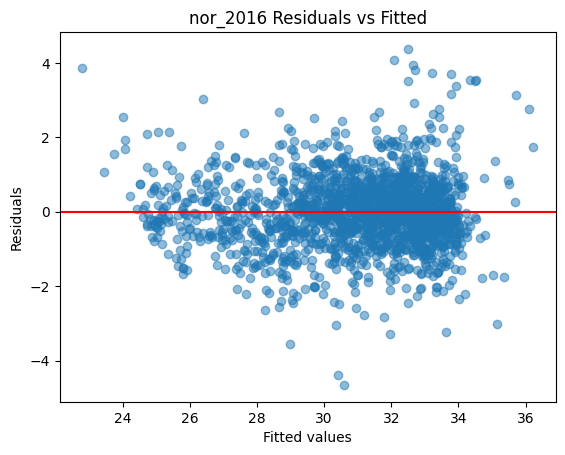

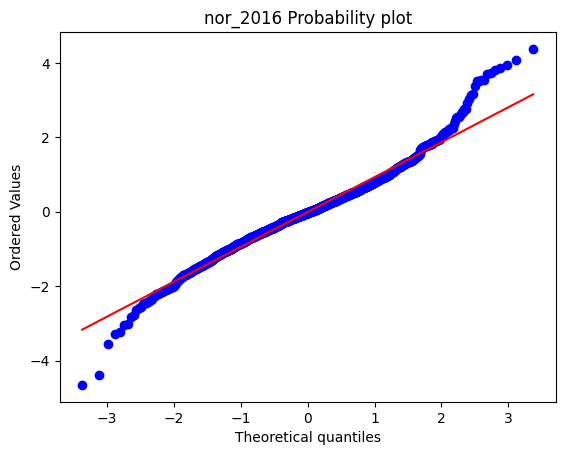

nor_2016 Shapiro-Wilk: stat 0.9762, p-value 0.0000
nor_2016 Breusch-Pagan test: F-stat 32.1767, p-value 0.0000
Moran's I:0.5074 p-value: 0.0010


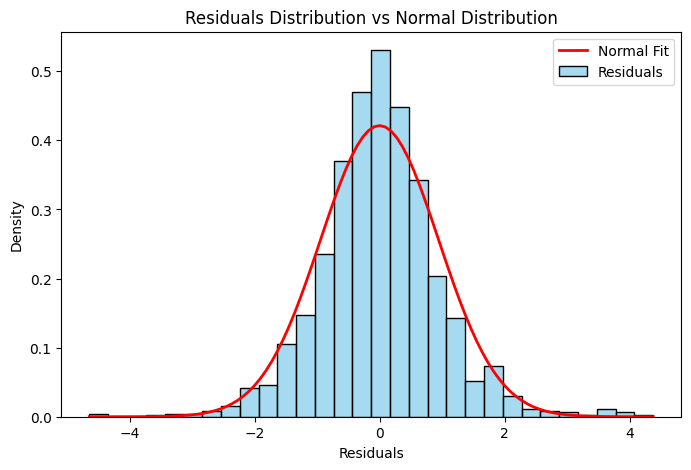

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


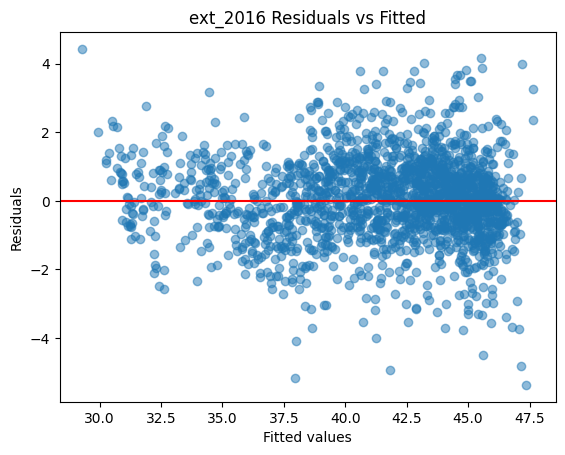

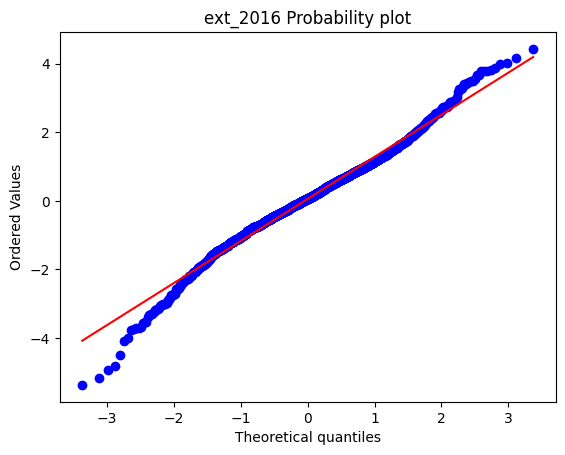

ext_2016 Shapiro-Wilk: stat 0.9871, p-value 0.0000
ext_2016 Breusch-Pagan test: F-stat 26.5322, p-value 0.0000
Moran's I:0.5406 p-value: 0.0010


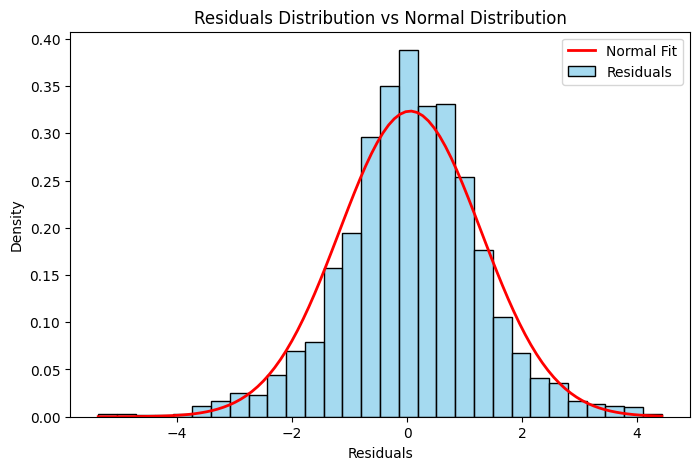

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


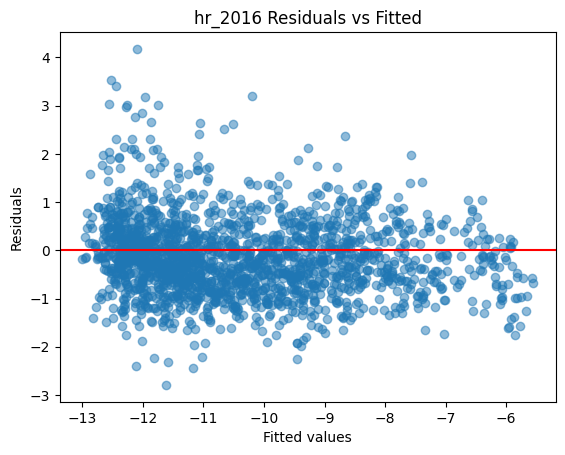

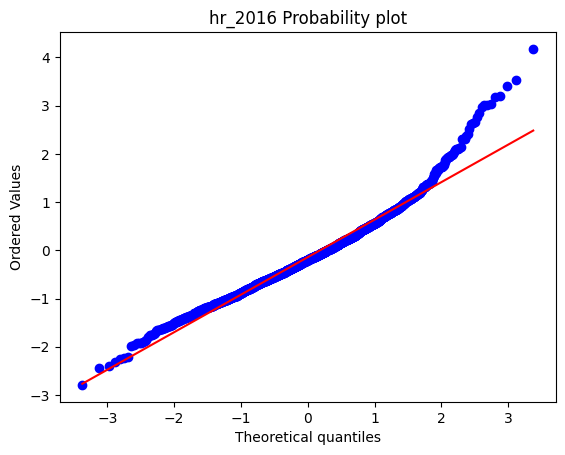

hr_2016 Shapiro-Wilk: stat 0.9699, p-value 0.0000
hr_2016 Breusch-Pagan test: F-stat 3.5193, p-value 0.0000
Moran's I:0.7046 p-value: 0.0010


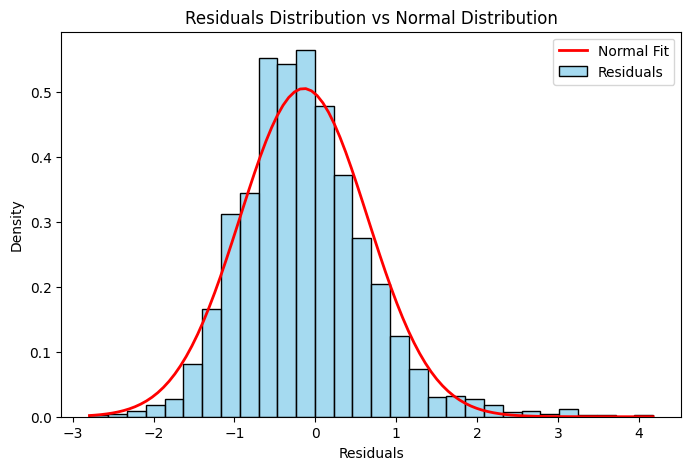

('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


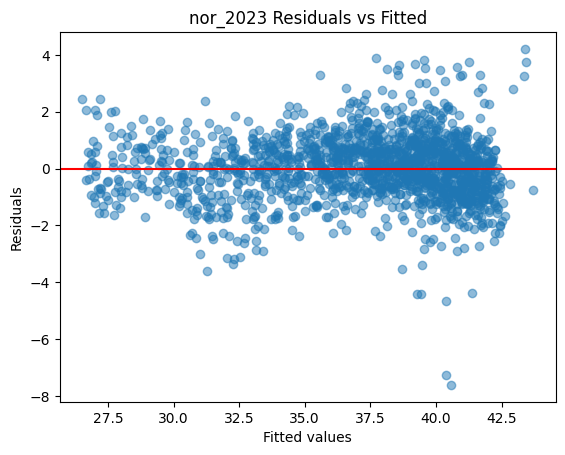

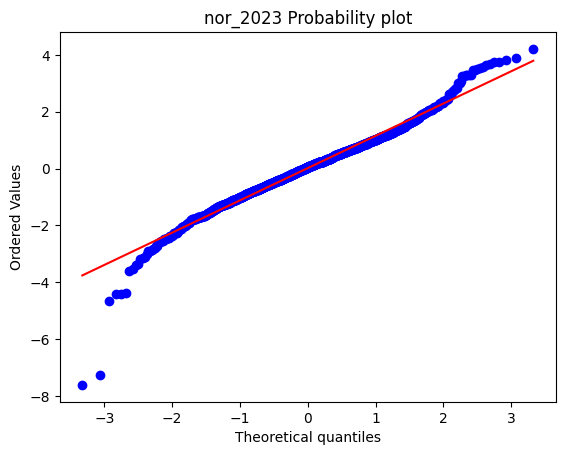

nor_2023 Shapiro-Wilk: stat 0.9740, p-value 0.0000
nor_2023 Breusch-Pagan test: F-stat 36.4341, p-value 0.0000
Moran's I:0.5222 p-value: 0.0010


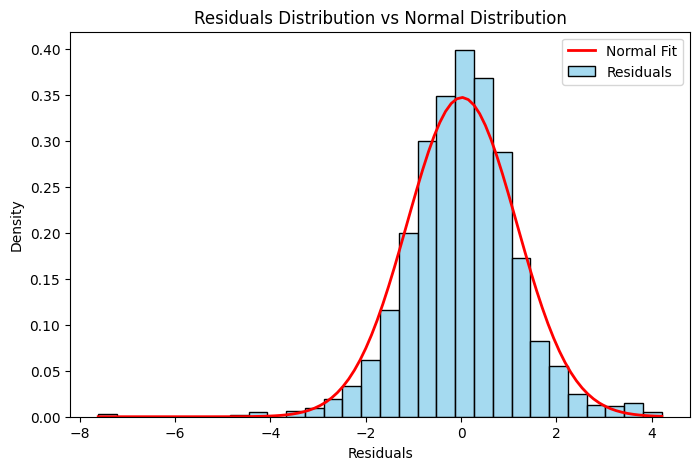

('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


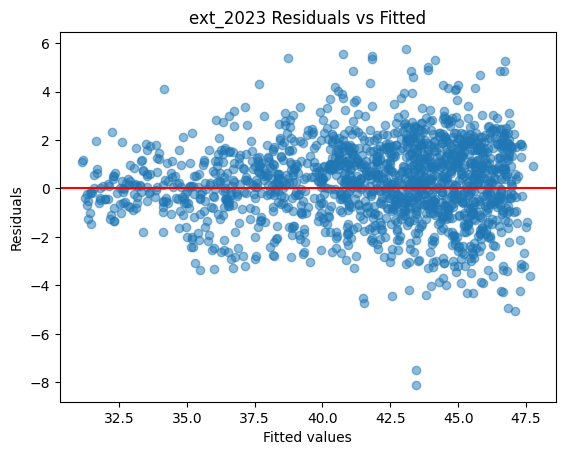

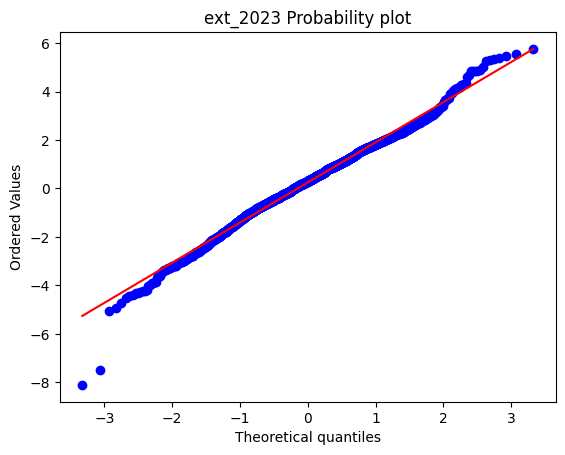

ext_2023 Shapiro-Wilk: stat 0.9913, p-value 0.0000
ext_2023 Breusch-Pagan test: F-stat 42.0387, p-value 0.0000
Moran's I:0.7262 p-value: 0.0010


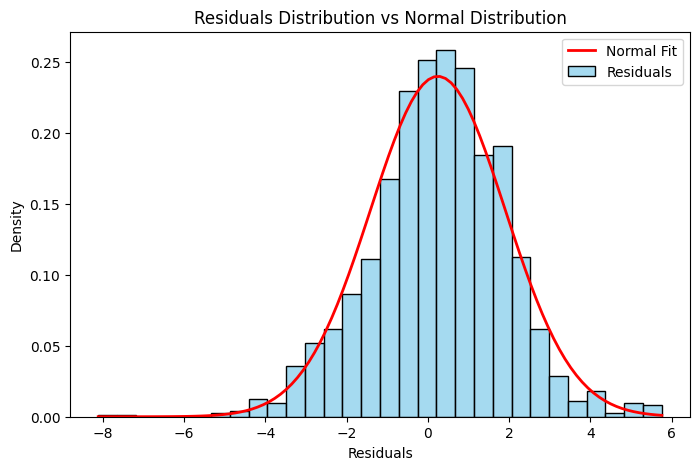

('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


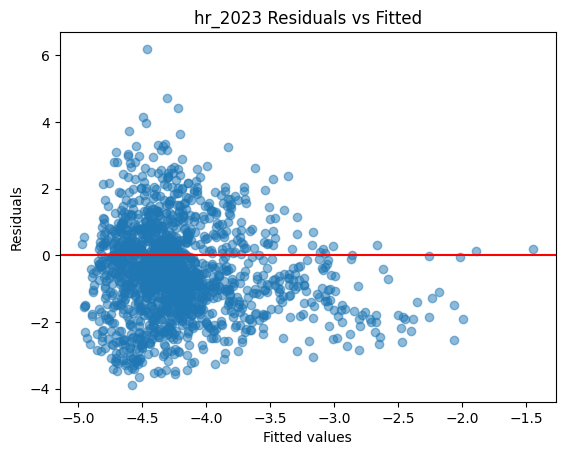

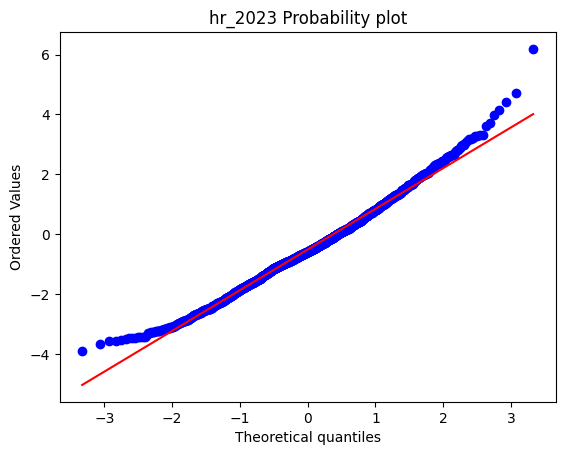

hr_2023 Shapiro-Wilk: stat 0.9906, p-value 0.0000
hr_2023 Breusch-Pagan test: F-stat 21.7271, p-value 0.0000
Moran's I:0.8483 p-value: 0.0010


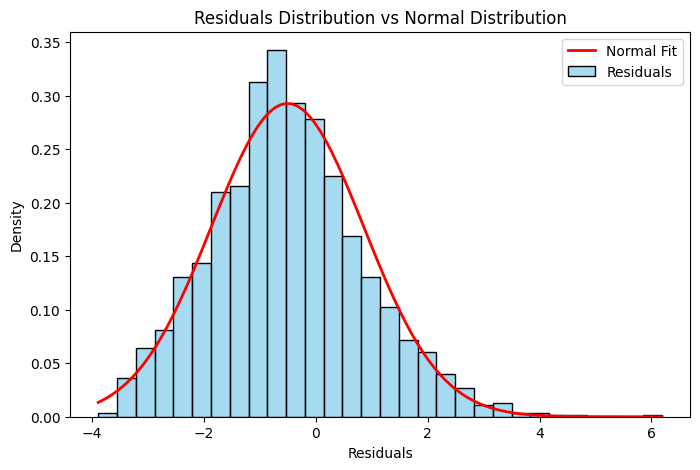

In [17]:
from libpysal.weights import DistanceBand, lag_spatial
from spreg import ML_Lag, ML_Error
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from esda.moran import Moran
import warnings
import sys
import seaborn as sns

# 1. 关闭所有 RuntimeWarning 和 UserWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# # 2. 临时屏蔽 stdout（针对 libpysal 直接 print 的 “island warning”）
class DummyFile(object):
    def write(self, x): pass
    def flush(self): pass


grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                        'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
    explanatory_vars_clean = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'WR(%)']

    results_by_target = {t: [] for t in target_vars}

    for filename in os.listdir(grid_folder):
        if filename.endswith('480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp') and filename.startswith(f'city{year}'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path).replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'

                # y
                y = data[target].values.reshape(-1, 1)

                # X: 原变量
                X_main = data[explanatory_vars].values
                # print(explanatory_vars)

                # WX_clean: 只 lag clean 变量
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                # print(explanatory_vars_clean)

                # 合并常数 + X_main + WX_clean
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])

                name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]

                # 模型
                model = ML_Error(
                    y, X_all,
                    w=w,
                    name_y=target,
                    name_x=name_x,
                    spat_diag=True,
                    spat_impacts=['simple','full']
                )
                residuals = model.u  # spreg 里残差是 model.u
                fitted = model.predy.flatten()
                plt.scatter(fitted, residuals, alpha=0.5)
                plt.axhline(0, color='red')
                plt.xlabel("Fitted values")
                plt.ylabel("Residuals")
                plt.title(f"{target} Residuals vs Fitted")
                plt.savefig(rf"D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\{target} Residuals vs Fitted.png")
                plt.show()
                residuals = model.u.flatten()   # 变成 (n,)

                stats.probplot(residuals, dist="norm", plot=plt)

                plt.title(f"{target} Probability plot")
                plt.savefig(rf"D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\{target} Probability plot.png")
                plt.show()


                residuals = model.u  # spreg 里残差是 model.u
                residuals = model.u.flatten()   # 变成 (n,)
                shapiro_res = stats.shapiro(residuals)
                print(f"{target} Shapiro-Wilk: stat {shapiro_res[0]:.4f}, p-value {shapiro_res[1]:.4f}")

                test = het_breuschpagan(residuals, X_all)
                print(f"{target} Breusch-Pagan test: F-stat {test[2]:.4f}, p-value {test[3]:.4f}")
                    
                mi = Moran(residuals, w)
                print(f"Moran's I:{mi.I:.4f}", f"p-value: {mi.p_sim:.4f}")

                # 绘制直方图和正态分布曲线
                plt.figure(figsize=(8,5))
                sns.histplot(residuals, bins=30, kde=False, color='skyblue', stat='density', label='Residuals')

                # 生成正态曲线
                mu, sigma = np.mean(residuals), np.std(residuals)
                x = np.linspace(min(residuals), max(residuals), 100)
                plt.plot(x, stats.norm.pdf(x, mu, sigma), color='red', lw=2, label='Normal Fit')

                plt.title('Residuals Distribution vs Normal Distribution')
                plt.xlabel('Residuals')
                plt.ylabel('Density')
                plt.legend()
                plt.savefig(rf"D:\seoul\grids\lst_map\final_clean\480_based\statistics\fig\{target} Residuals Distribution vs Normal Distribution.png")
                plt.show()

# 02 使用机器学习模型分析

## 01 GBDT